In [7]:
from pathlib import Path
import glob
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

In [8]:
HISTORY_RE = re.compile(r'(?P<name>.+)_(?P<region>mouth|nose)_s(?P<seed>\d+)_history$')
REGIONS = ['mouth', 'nose']
REGION_COLORS = {'mouth': 'tab:blue', 'nose': 'tab:orange'}
RANK_COLORS = {"beta": 'tab:green', "lag": 'tab:purple', "combined": 'tab:red'}

# architectures
ARCHITECTURES = ['conv_baseline', 'conv_slim', 'mlp', 'mlp_small', 'conv_asym']
LATENT_DIM = 16
WARMUP_END = 250
ARCHITECTURES_LABELS = {'conv_baseline': 'Conv Baseline',
               'conv_slim': 'Conv Slim',
               'mlp': 'MLP',
               'mlp_small': 'MLP Small',
               'conv_asym': 'Conv Asym'}
ARCHITECTURES_COLORS = dict(zip(ARCHITECTURES, sns.color_palette('tab10', n_colors=len(ARCHITECTURES))))

# dynamics
BETA_CONFIGS = ['beta_cap_0.001', 'beta_cap_0.01', 'beta_cap_0.1', 'beta_cap_0.5', 'beta_cap_1.0']
BETA_VALUES = {'beta_cap_0.001': 0.001,
               'beta_cap_0.01': 0.01,
               'beta_cap_0.1': 0.1,
               'beta_cap_0.5': 0.5,
               'beta_cap_1.0': 1.0,}
BETA_COLORS = dict(zip(BETA_CONFIGS, sns.color_palette('Blues', n_colors=len(BETA_CONFIGS) + 2)[2:]))
LAG_CONFIGS = ['lag_5_100', 'lag_5_250', 'lag_10_100', 'lag_10_250']
LAG_COLORS = {"beta_cap_1.0": "#4d4d4d", **dict(zip(LAG_CONFIGS, sns.color_palette("viridis", n_colors=len(LAG_CONFIGS) + 3)[1:-2]))}
COMBINED_CONFIGS = ['lag_5_250_beta_0.01', 'lag_5_250_beta_0.1']
CONFIG_LABELS = {'beta_cap_0.001': 'β-cap 0.001',
                 'beta_cap_0.01': 'β-cap 0.01',
                 'beta_cap_0.1': 'β-cap 0.1',
                 'beta_cap_0.5': 'β-cap 0.5',
                 'beta_cap_1.0': 'β-cap 1.0',
                 'lag_5_100': 'Lag 5 / 100',
                 'lag_5_250': 'Lag 5 / 250',
                 'lag_10_100': 'Lag 10 / 100',
                 'lag_10_250': 'Lag 10 / 250',
                 'lag_5_250_beta_0.01': 'Lag 5 / 250 + β 0.01',
                 'lag_5_250_beta_0.1': 'Lag 5 / 250 + β 0.1',}
DYNAMICS_CONFIGS = BETA_CONFIGS + LAG_CONFIGS + COMBINED_CONFIGS


In [9]:
# load data
def load_histories(directory, key_col):
    frames = []
    for path_str in sorted(glob.glob(str(Path(directory) / '*_history.csv'))):
        path = Path(path_str)
        match = HISTORY_RE.match(path.stem)
        if match is None:
            raise ValueError(f'Unexpected history filename: {path.name}')
        frame = pd.read_csv(path)
        frame[key_col] = match.group('name')
        frame['region'] = match.group('region')
        frame['seed'] = int(match.group('seed'))
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

arch_summary = pd.read_csv('./results/ablation_cvae_architecture/summary.csv')
arch_summary['variant'] = pd.Categorical(arch_summary['variant'], categories=ARCHITECTURES, ordered=True)
arch_summary = arch_summary.sort_values(['region', 'variant', 'seed']).reset_index(drop=True)

arch_history = load_histories('./results/ablation_cvae_architecture', 'variant')
arch_history['variant'] = pd.Categorical(arch_history['variant'], categories=ARCHITECTURES, ordered=True)
arch_history = arch_history.sort_values(['region', 'variant', 'seed', 'epoch']).reset_index(drop=True)

dyn_summary = pd.read_csv('./results/ablation_cvae_training_dynamics/summary.csv')
dyn_summary['config'] = pd.Categorical(dyn_summary['config'], categories=DYNAMICS_CONFIGS, ordered=True)
dyn_summary = dyn_summary.sort_values(['region', 'config', 'seed']).reset_index(drop=True)

dyn_history = load_histories('./results/ablation_cvae_training_dynamics', 'config')
dyn_history['config'] = pd.Categorical(dyn_history['config'], categories=DYNAMICS_CONFIGS, ordered=True)
dyn_history = dyn_history.sort_values(['region', 'config', 'seed', 'epoch']).reset_index(drop=True)

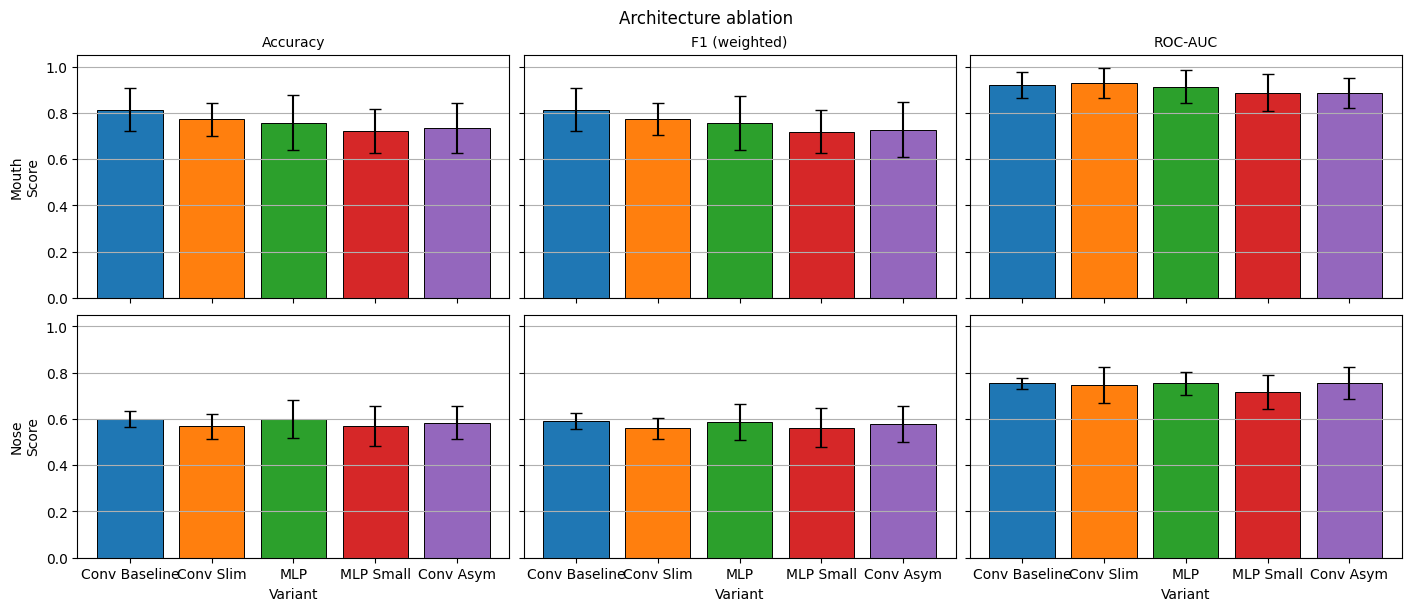

                      accuracy           f1_weighted             roc_auc  \
                          mean       std        mean       std      mean   
region variant                                                             
mouth  conv_baseline  0.814286  0.092444    0.812792  0.093119  0.920409   
       conv_slim      0.771429  0.069620    0.773217  0.067624  0.930624   
       mlp            0.757143  0.119523    0.756219  0.118328  0.912320   
       mlp_small      0.721429  0.095831    0.719094  0.093561  0.887290   
       conv_asym      0.735714  0.108914    0.727292  0.118017  0.887018   
nose   conv_baseline  0.600000  0.034312    0.591097  0.034928  0.752996   
       conv_slim      0.568421  0.054570    0.558668  0.045967  0.746765   
       mlp            0.600000  0.081960    0.586639  0.077687  0.754363   
       mlp_small      0.568421  0.086483    0.562741  0.083284  0.714526   
       conv_asym      0.584211  0.073023    0.576056  0.077998  0.754517   

           

In [10]:
plot_metrics = ['accuracy', 'f1_weighted', 'roc_auc']
plot_titles = {'accuracy': 'Accuracy',
               'f1_weighted': 'F1 (weighted)',
               'roc_auc': 'ROC-AUC'}

# stats
arch_stats = arch_summary.groupby(['region', 'variant'], observed=True)[plot_metrics].agg(['mean', 'std'])

# plots
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex='col', sharey='row', constrained_layout=True)
x = np.arange(len(ARCHITECTURES))
for row_idx, region in enumerate(REGIONS):
    for col_idx, metric in enumerate(plot_metrics):
        ax = axes[row_idx, col_idx]
        means = arch_stats.loc[(region,), (metric, 'mean')].reindex(ARCHITECTURES).to_numpy()
        stds = arch_stats.loc[(region,), (metric, 'std')].reindex(ARCHITECTURES).to_numpy()
        ax.bar(x, means, yerr=stds, capsize=4, color=[ARCHITECTURES_COLORS[v] for v in ARCHITECTURES], edgecolor='black', linewidth=0.7)
        ax.set_xticks(x, [ARCHITECTURES_LABELS[v] for v in ARCHITECTURES])
        ax.set_ylim(0, 1.05)
        ax.set_xlabel('Variant') if row_idx == len(REGIONS) - 1 else None
        ax.set_title(plot_titles[metric]) if row_idx == 0 else None
        ax.set_ylabel(f'{region.capitalize()}\nScore') if col_idx == 0 else None
        ax.grid(axis='y')
fig.suptitle('Architecture ablation')
plt.show()
print(arch_stats)

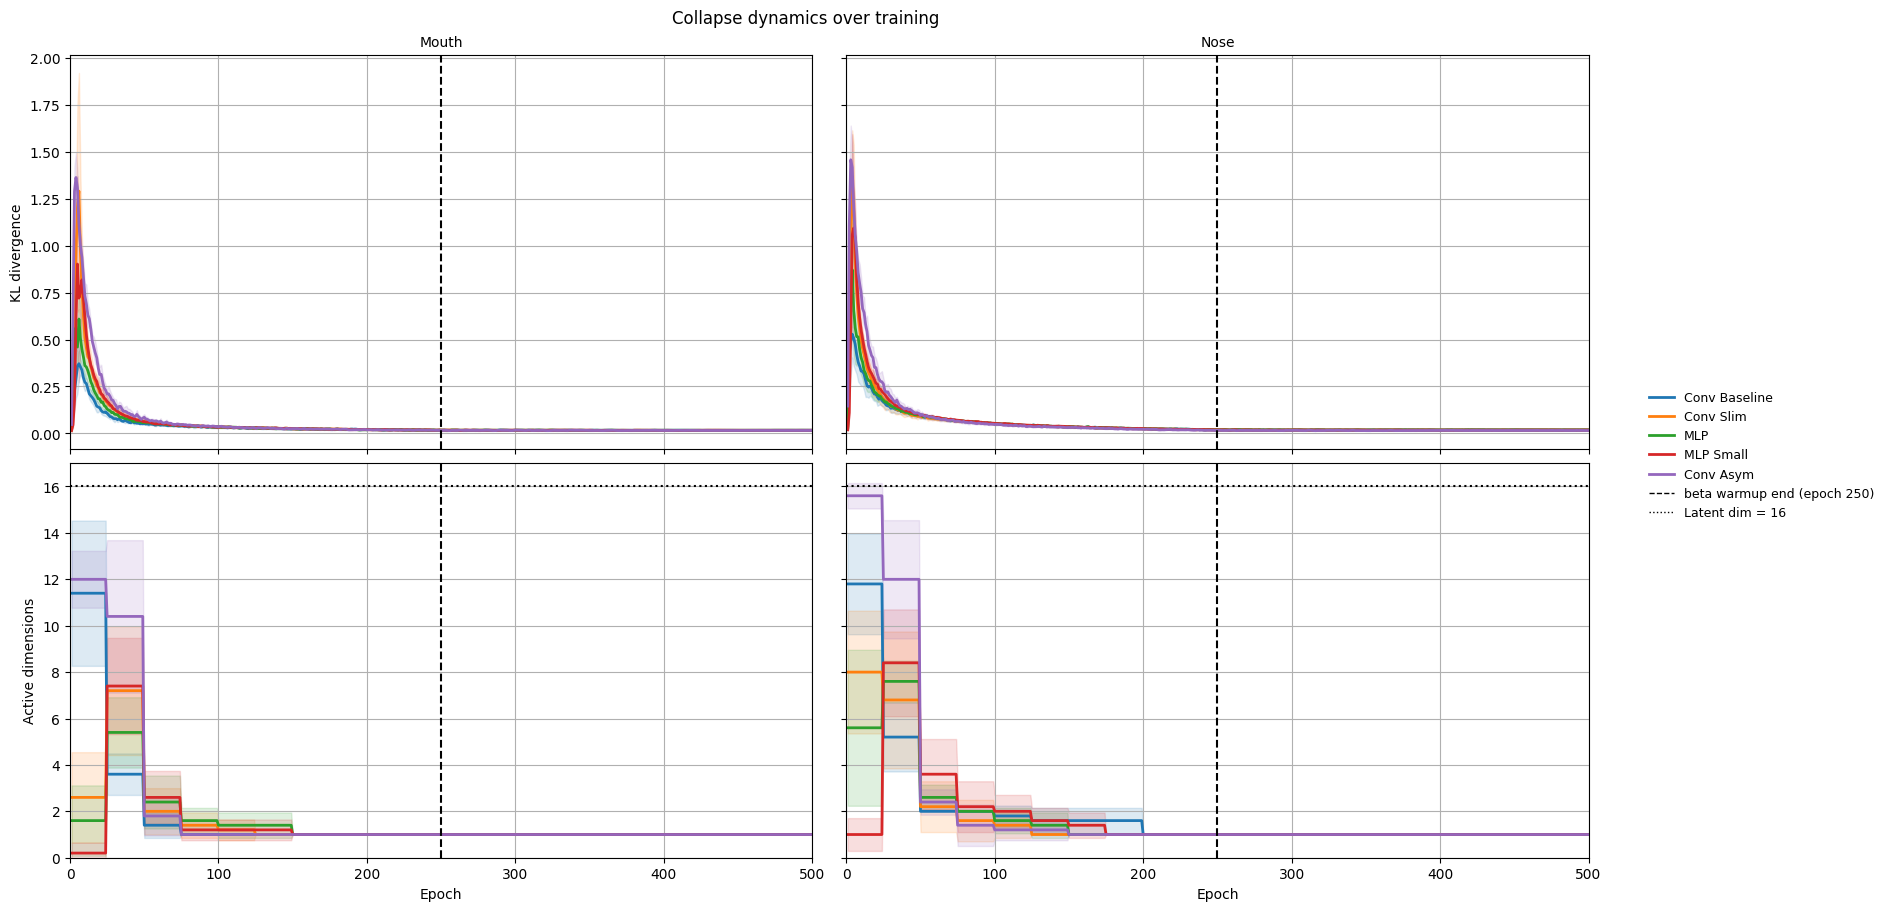

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey='row', constrained_layout=True)
for col_idx, region in enumerate(REGIONS):
    ax_kl = axes[0, col_idx]
    ax_ad = axes[1, col_idx]

    for variant in ARCHITECTURES:
        curve = (arch_history[(arch_history['region'] == region) & (arch_history['variant'] == variant)]
                    .groupby('epoch', observed=True)[['train_kl', 'active_dims']]
                    .agg(['mean', 'std']))
        epochs = curve.index.to_numpy()
        kl_mean = curve[('train_kl', 'mean')].to_numpy()
        kl_std = curve[('train_kl', 'std')].fillna(0).to_numpy()
        ad_mean = curve[('active_dims', 'mean')].to_numpy()
        ad_std = curve[('active_dims', 'std')].fillna(0).to_numpy()
        color = ARCHITECTURES_COLORS[variant]

        ax_kl.plot(epochs, kl_mean, color=color, linewidth=2, label=ARCHITECTURES_LABELS[variant])
        ax_kl.fill_between(epochs, kl_mean - kl_std, kl_mean + kl_std, color=color, alpha=0.15)
        ax_ad.plot(epochs, ad_mean, color=color, linewidth=2, label=ARCHITECTURES_LABELS[variant])
        ax_ad.fill_between(epochs, ad_mean - ad_std, ad_mean + ad_std, color=color, alpha=0.15)

    ax_kl.axvline(WARMUP_END, color='black', linestyle='--')
    ax_ad.axvline(WARMUP_END, color='black', linestyle='--')
    ax_ad.axhline(LATENT_DIM, color='black', linestyle=':')

    ax_kl.set_title(f'{region.capitalize()}')
    ax_kl.set_ylabel('KL divergence') if col_idx == 0 else None
    ax_ad.set_ylabel('Active dimensions') if col_idx == 0 else None
    ax_ad.set_xlabel('Epoch') if row_idx == 1 else None
    ax_kl.set_xlabel('Epoch') if row_idx == 0 else None
    ax_kl.set_xlim(0, arch_history['epoch'].max())
    ax_ad.set_xlim(0, arch_history['epoch'].max())
    ax_ad.set_ylim(0, LATENT_DIM + 1)
    ax_kl.grid()
    ax_ad.grid()

handles = [Line2D([0], [0], color=ARCHITECTURES_COLORS[v], lw=2, label=ARCHITECTURES_LABELS[v]) for v in ARCHITECTURES]
handles += [Line2D([0], [0], color='black', lw=1, linestyle='--', label='beta warmup end (epoch 250)'),
            Line2D([0], [0], color='black', lw=1, linestyle=':', label='Latent dim = 16')]
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle('Collapse dynamics over training')
plt.show()

Best β-cap config for Mouth: β-cap 0.1
Best β-cap config for Nose: β-cap 0.01


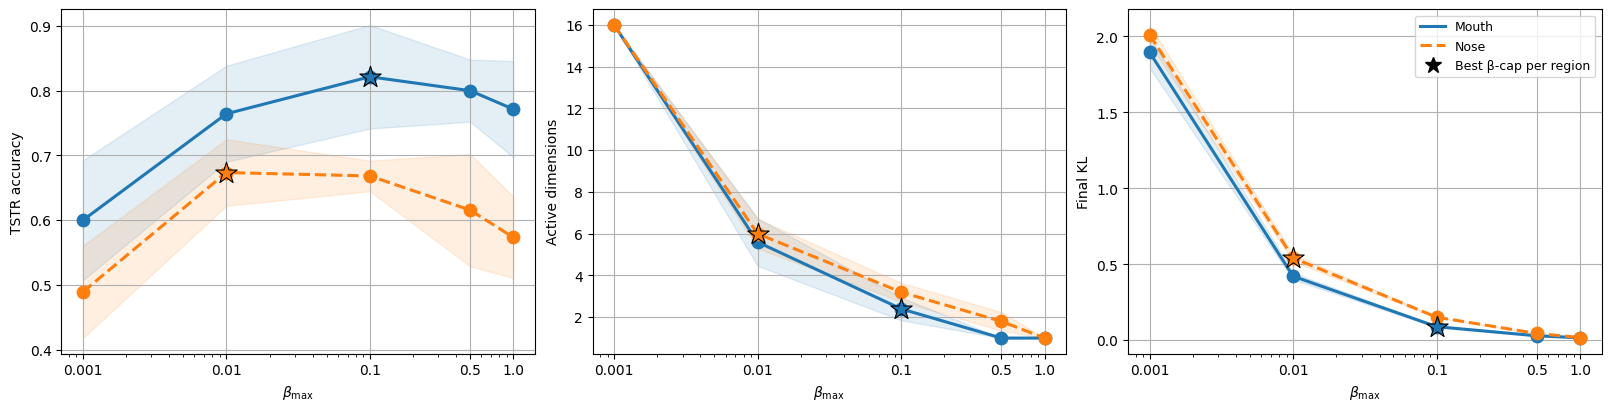

In [12]:
beta_only = dyn_summary[dyn_summary['config'].isin(BETA_CONFIGS)].copy()
beta_only['beta_max'] = beta_only['config'].map(BETA_VALUES).astype(float)

beta_best = (beta_only.groupby(['region', 'config'], observed=True)['accuracy'].mean()
                .groupby('region', observed=True)
                .idxmax())
beta_best = {region: cfg for region, (_, cfg) in beta_best.items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
metrics = ['accuracy', 'active_dims', 'kl_final']
ylabels = {'accuracy': 'TSTR accuracy',
           'active_dims': 'Active dimensions',
           'kl_final': 'Final KL'}

for ax, metric in zip(axes, metrics):
    for region, linestyle in zip(REGIONS, ['-', '--']):
        stats = (beta_only[beta_only['region'] == region]
                .groupby('beta_max', observed=True)[metric]
                .agg(['mean', 'std'])
                .reindex([BETA_VALUES[cfg] for cfg in BETA_CONFIGS]))
        x = stats.index.to_numpy(dtype=float)
        y = stats['mean'].to_numpy(dtype=float)
        std = stats['std'].fillna(0).to_numpy(dtype=float)

        ax.plot(x, y, color=REGION_COLORS[region], linewidth=2.2, linestyle=linestyle, label=region.capitalize())
        ax.fill_between(x, y - std, y + std, color=REGION_COLORS[region], alpha=0.12)
        ax.scatter(x, y, s=80, c=REGION_COLORS[region], edgecolor=REGION_COLORS[region], linewidth=1.0, zorder=3)

        best_cfg = beta_best[region]
        best_x = BETA_VALUES[best_cfg]
        best_y = stats.loc[best_x, 'mean']
        ax.scatter([best_x], [best_y], marker='*', s=260, color=REGION_COLORS[region], edgecolor='black', linewidth=0.8, zorder=4,)

    ax.set_xscale('log')
    ax.set_xticks([BETA_VALUES[cfg] for cfg in BETA_CONFIGS], [str(BETA_VALUES[cfg]) for cfg in BETA_CONFIGS])
    ax.set_xlabel(r'$\beta_{\max}$')
    ax.set_ylabel(ylabels[metric])
    # ax.set_title(ylabels[metric])
    ax.grid()

handles = [
    Line2D([0], [0], color=REGION_COLORS[region], linestyle=style, lw=2.2, label=region.capitalize())
    for region, style in zip(REGIONS, ['-', '--'])
]
handles.append(Line2D([0], [0], marker='*', color='black', lw=0, markersize=12, label='Best β-cap per region'))
ax.legend(handles=handles, loc='upper right')
# fig.suptitle('β-cap sweep: accuracy, active dimensions, and KL vs β_max', y=1.12)


plt.savefig('results/figures/beta_sweep.pdf')
for region in REGIONS:
    print(f'Best β-cap config for {region.capitalize()}: {CONFIG_LABELS[beta_best[region]]}')

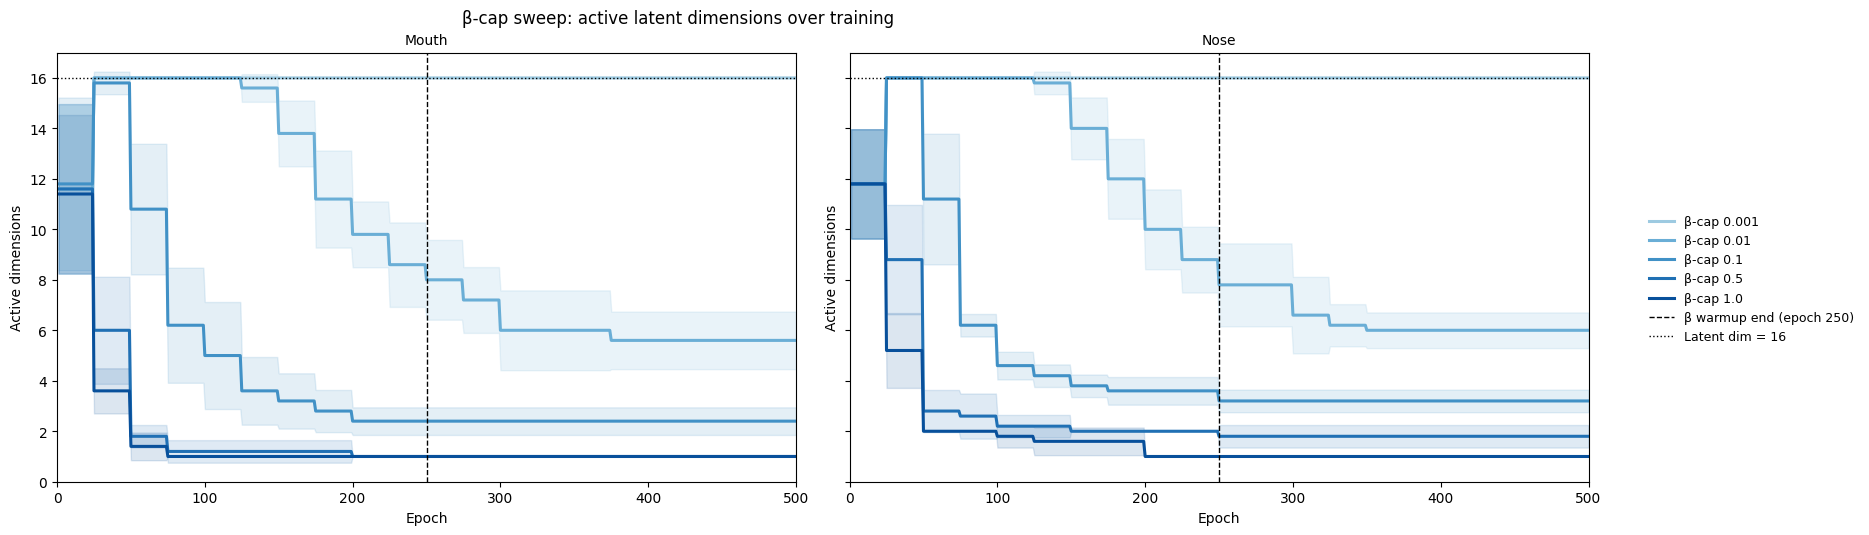

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True, constrained_layout=True)

for ax, region in zip(axes, REGIONS):
    for cfg in BETA_CONFIGS:
        curve = (
            dyn_history[(dyn_history["region"] == region) & (dyn_history["config"] == cfg)]
            .groupby("epoch", observed=True)["active_dims"]
            .agg(["mean", "std"])
        )
        epochs = curve.index.to_numpy()
        mean = curve["mean"].to_numpy(dtype=float)
        std = curve["std"].fillna(0).to_numpy(dtype=float)
        color = BETA_COLORS[cfg]
        ax.plot(epochs, mean, color=color, linewidth=2.2, label=CONFIG_LABELS[cfg])
        ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.14)

    ax.axvline(WARMUP_END, color="black", linestyle="--", linewidth=1)
    ax.axhline(LATENT_DIM, color="black", linestyle=":", linewidth=1)
    ax.set_title(region.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Active dimensions")
    ax.set_xlim(0, dyn_history["epoch"].max())
    ax.set_ylim(0, LATENT_DIM + 1)

handles = [Line2D([0], [0], color=BETA_COLORS[cfg], lw=2.2, label=CONFIG_LABELS[cfg]) for cfg in BETA_CONFIGS]
handles += [Line2D([0], [0], color="black", lw=1, linestyle="--", label="β warmup end (epoch 250)"),
            Line2D([0], [0], color="black", lw=1, linestyle=":", label="Latent dim = 16")]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle("β-cap sweep: active latent dimensions over training", x=0.42, y=1.04)
plt.show()

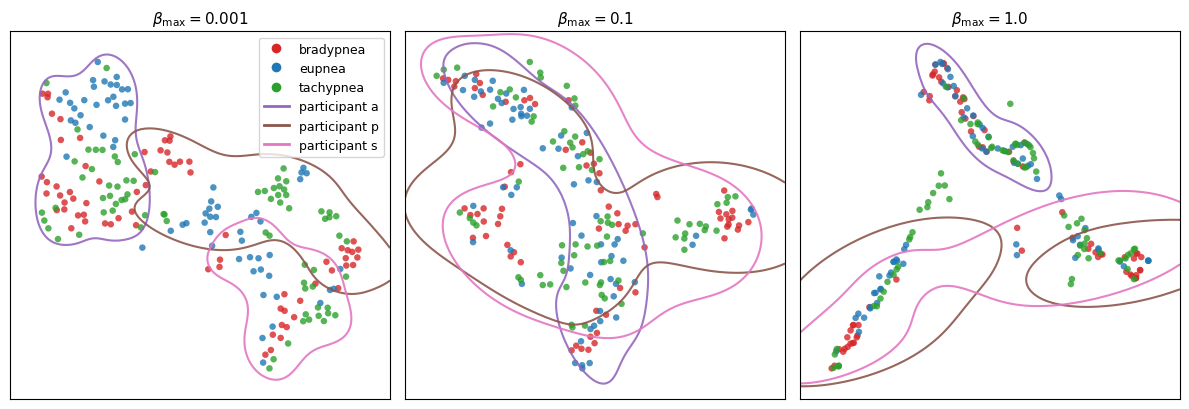

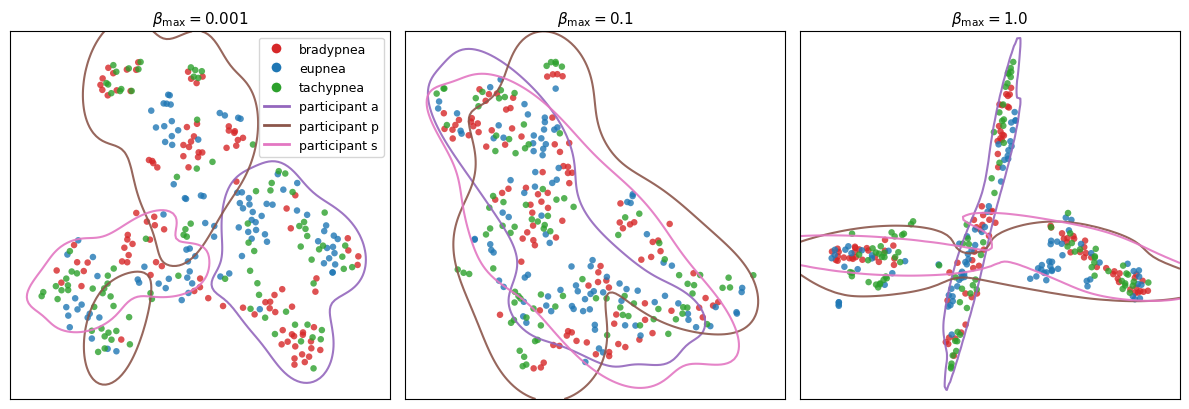

In [14]:
import torch
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde

from models.vae import CVAE
from core.data import BreathDataset, load_dataset, split_dataset

TSNE_MODEL_SEED = 0
TSNE_RANDOM_STATE = 0
PERPLEXITY = 30.0
TSNE_BETA_CONFIGS = ['beta_cap_0.001', 'beta_cap_0.1', 'beta_cap_1.0']

CLASS_NAMES = ['bradypnea', 'eupnea', 'tachypnea']
PARTICIPANT_NAMES = ['a', 'p', 's']
class_colors = ['#d62728', '#1f77b4', '#2ca02c']
part_colors  = ['#9467bd', '#8c564b', '#e377c2']

device = torch.device('cpu')


@torch.no_grad()
def cvae_encoder_outputs(model, dataset):
    """Encode every sample in `dataset` with its true (y, p) conditioning."""
    mus, logvars = [], []
    model.eval()
    for i in range(len(dataset)):
        signal, _, label, part = dataset[i]
        y = torch.tensor([label], dtype=torch.long, device=device)
        p = torch.tensor([part], dtype=torch.long, device=device) if model._cond_part else None
        mu, logvar = model.encoder(signal.unsqueeze(0).to(device), y, p)
        mus.append(mu.squeeze(0).cpu())
        logvars.append(logvar.squeeze(0).cpu())
    return torch.stack(mus), torch.stack(logvars)


def participant_contours(ax, emb, parts, colors, levels=(0.5,), grid_size=120, pad=0.1):
    """Overlay a KDE contour per participant at the specified density level(s)."""
    x_min, x_max = emb[:, 0].min(), emb[:, 0].max()
    y_min, y_max = emb[:, 1].min(), emb[:, 1].max()
    dx = (x_max - x_min) * pad
    dy = (y_max - y_min) * pad
    xx, yy = np.meshgrid(
        np.linspace(x_min - dx, x_max + dx, grid_size),
        np.linspace(y_min - dy, y_max + dy, grid_size),
    )
    grid = np.vstack([xx.ravel(), yy.ravel()])

    for pi, color in enumerate(colors):
        pts = emb[parts == pi]
        if len(pts) < 5:
            continue
        try:
            kde = gaussian_kde(pts.T)
        except np.linalg.LinAlgError:
            continue
        density = kde(grid).reshape(xx.shape)
        flat = np.sort(density.ravel())[::-1]
        cumulative = np.cumsum(flat) / flat.sum()
        thresholds = [flat[np.searchsorted(cumulative, lvl)] for lvl in levels]
        ax.contour(xx, yy, density, levels=sorted(thresholds),
                   colors=[color], linewidths=1.5, alpha=0.9)


for region in REGIONS:
    df = load_dataset()
    df = df[df['region'] == region].reset_index(drop=True)
    df_train, _, _ = split_dataset(df, random_state=TSNE_MODEL_SEED)
    train_ds = BreathDataset(df_train)

    classes = np.array([train_ds[i][2] for i in range(len(train_ds))])
    parts   = np.array([train_ds[i][3] for i in range(len(train_ds))])

    fig, axes = plt.subplots(1, len(TSNE_BETA_CONFIGS), figsize=(4 * len(TSNE_BETA_CONFIGS), 4.2))

    for c_idx, cfg in enumerate(TSNE_BETA_CONFIGS):
        ax = axes[c_idx]
        ckpt_path = f'results/ablation_cvae_training_dynamics/{cfg}_{region}_s{TSNE_MODEL_SEED}.pt'
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model = CVAE(latent_dim=ckpt['latent_dim'],
                     embed_dim=ckpt['embed_dim'],
                     condition_on_participant=True,
                     part_embed_dim=ckpt['part_embed_dim']).to(device)
        model.load_state_dict(ckpt['model_state'])

        mu, _ = cvae_encoder_outputs(model, train_ds)
        mu = mu.numpy()

        eff_perp = min(PERPLEXITY, max(5, (len(mu) - 1) // 3))
        emb = TSNE(n_components=2, perplexity=eff_perp,
                   random_state=TSNE_RANDOM_STATE,
                   init='pca', learning_rate='auto').fit_transform(mu)

        for ci, name in enumerate(CLASS_NAMES):
            mask = classes == ci
            ax.scatter(emb[mask, 0], emb[mask, 1], c=class_colors[ci],
                       label=name if c_idx == 0 else None,
                       s=22, alpha=0.8, edgecolors='none')

        participant_contours(ax, emb, parts, part_colors, levels=(0.8,))

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(rf'$\beta_{{\max}} = {BETA_VALUES[cfg]}$', fontsize=11)

    class_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                            markersize=8, label=name)
                     for c, name in zip(class_colors, CLASS_NAMES)]
    part_handles = [Line2D([0], [0], color=c, linewidth=2,
                           label=f'participant {name}')
                    for c, name in zip(part_colors, PARTICIPANT_NAMES)]
    axes[0].legend(handles=class_handles + part_handles, loc='best', ncol=1)

    plt.tight_layout()
    plt.savefig(f'results/figures/05_{region}_cvae_tsne.png', dpi=500)
    plt.show()

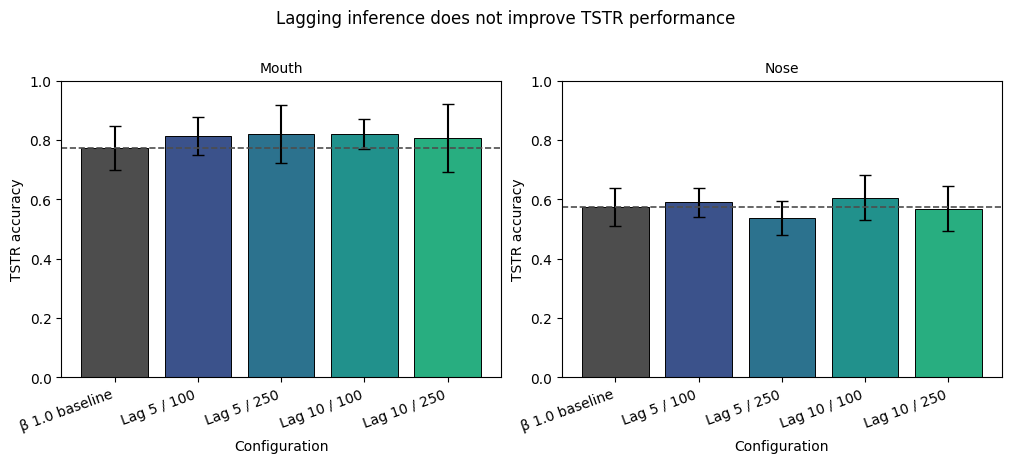

In [15]:
lag_plot_configs = ["beta_cap_1.0", *LAG_CONFIGS]
lag_plot_labels = {"beta_cap_1.0": "β 1.0 baseline",
                   "lag_5_100": "Lag 5 / 100",
                   "lag_5_250": "Lag 5 / 250",
                   "lag_10_100": "Lag 10 / 100",
                   "lag_10_250": "Lag 10 / 250",}
lag_stats = dyn_summary[dyn_summary["config"].isin(lag_plot_configs)].groupby(["region", "config"], observed=True)[["accuracy", "active_dims"]].agg(["mean", "std"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False, constrained_layout=True)
x = np.arange(len(lag_plot_configs))
colors = [LAG_COLORS[cfg] for cfg in lag_plot_configs]

for ax, region in zip(axes, REGIONS):
    means = lag_stats.loc[(region,), ("accuracy", "mean")].reindex(lag_plot_configs).to_numpy()
    stds = lag_stats.loc[(region,), ("accuracy", "std")].reindex(lag_plot_configs).to_numpy()
    baseline_acc = means[0]

    ax.bar(x, means, yerr=stds, capsize=4, color=colors, edgecolor="black", linewidth=0.7)
    ax.axhline(baseline_acc, color=LAG_COLORS["beta_cap_1.0"], linestyle="--", linewidth=1.2)
    ax.set_xticks(x, [lag_plot_labels[cfg] for cfg in lag_plot_configs], rotation=20, ha="right")
    ax.set_title(region.capitalize())
    ax.set_xlabel("Configuration")
    ax.set_ylabel("TSTR accuracy")
    ax.set_ylim(0, max(1.0, means.max() + stds.max() + 0.05))
fig.suptitle("Lagging inference does not improve TSTR performance", y=1.12)
plt.show()

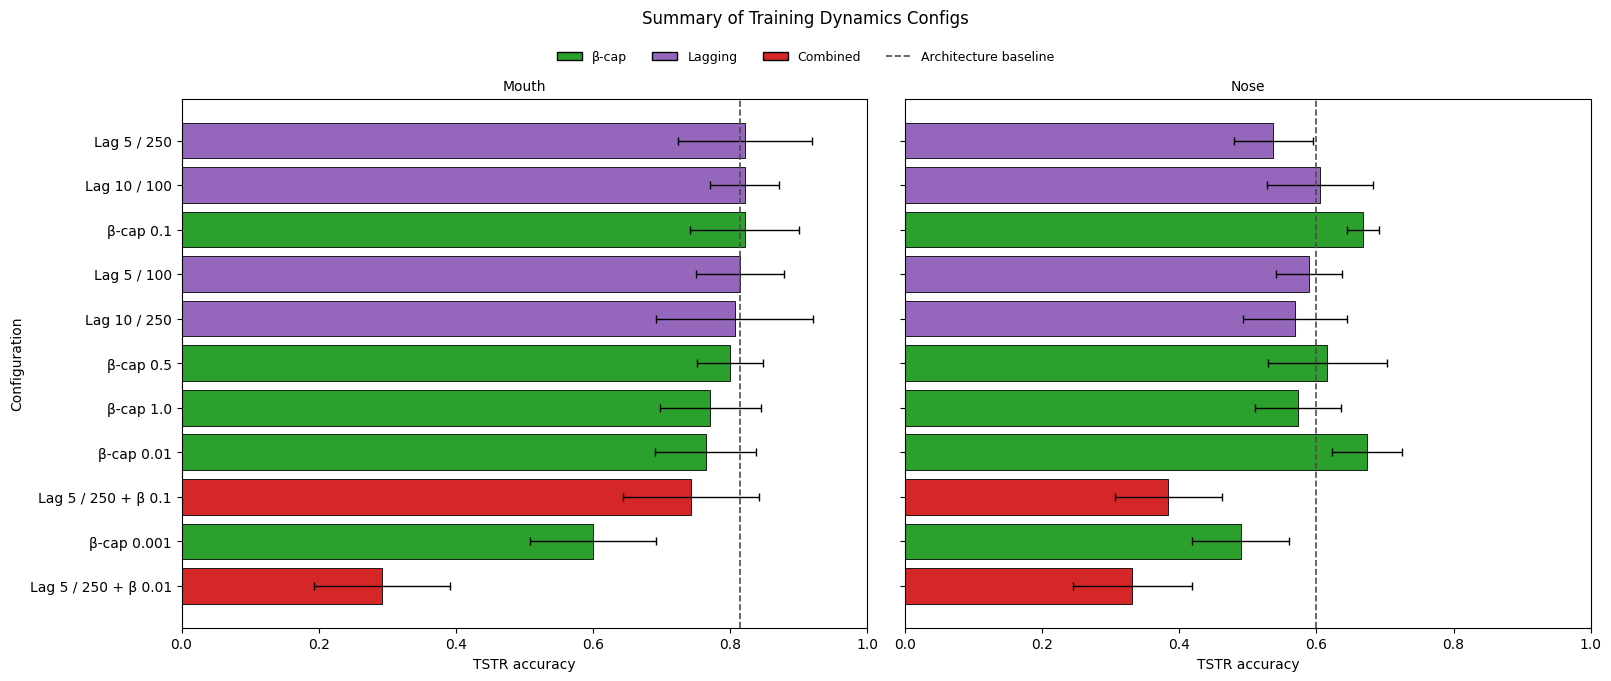

In [16]:
def family_of_config(config):
    if config in BETA_CONFIGS:
        return "beta"
    if config in LAG_CONFIGS:
        return "lag"
    return "combined"

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False, sharey='row', constrained_layout=True)
for ax, region in zip(axes, REGIONS):
    stats = (
        dyn_summary[dyn_summary["region"] == region]
        .groupby("config", observed=True)["accuracy"]
        .agg(["mean", "std"])
        .sort_values("mean", ascending=True)
    )
    labels = [CONFIG_LABELS[cfg] for cfg in stats.index]
    colors = [RANK_COLORS[family_of_config(cfg)] for cfg in stats.index]
    ax.barh(
        labels,
        stats["mean"].values,
        xerr=stats["std"].fillna(0).values,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
        capsize=3,
        error_kw={"elinewidth": 1.0, "ecolor": "black"},
    )
    baseline_arch = arch_summary[(arch_summary["region"] == region) & (arch_summary["variant"] == "conv_baseline")]["accuracy"].mean()
    ax.axvline(baseline_arch, color="#4d4d4d", linestyle="--", linewidth=1.2)
    ax.set_title(region.capitalize())
    ax.set_xlabel("TSTR accuracy")
    ax.set_ylabel("Configuration") if ax == axes[0] else None
    ax.set_xlim(0, 1.0)

legend_handles = [
    Patch(facecolor=RANK_COLORS["beta"], edgecolor="black", label="β-cap"),
    Patch(facecolor=RANK_COLORS["lag"], edgecolor="black", label="Lagging"),
    Patch(facecolor=RANK_COLORS["combined"], edgecolor="black", label="Combined"),
    Line2D([0], [0], color="#4d4d4d", linestyle="--", lw=1.2, label="Architecture baseline"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=4, frameon=False)
fig.suptitle("Summary of Training Dynamics Configs", y=1.11)
plt.show()

In [ ]:
# from ablations.cvae_jittering import print_summary

# df = pd.read_csv('results/ablation_jitter/summary.csv')
# print_summary(df.to_dict('records'))

FileNotFoundError: [Errno 2] No such file or directory: 'results/ablation_jitter/summary.csv'

In [ ]:
!jupyter nbconvert cvae.ipynb --to pdf --no-input --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_cell_tags='{"remove_cell"}'

[NbConvertApp] Converting notebook cvae.ipynb to pdf
[NbConvertApp] Support files will be in cvae_files/
[NbConvertApp] Making directory ./cvae_files
[NbConvertApp] Writing 25677 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 410068 bytes to cvae.pdf
